<a href="https://colab.research.google.com/github/ms-eea/myportfoliowebsite/blob/main/Cloud_Observability_FinOps_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

```markdown
# Synthetic Telemetry & FinOps Cost Model Notebook

This notebook simulates multi-cloud telemetry data (AWS/Azure resource utilization, unattached EBS volumes, over-provisioned Kubernetes pods, and idle compute instances). It generates automated cost-anomaly alerts, unit-economic cost per active user metrics, and an optimization recommendation table.

## Cells Overview:
- **Cell 1: Synthetic Telemetry Data Generation** — Creates a mock dataset of 5,000 cloud instances across AWS EC2, Azure VMs, and GCP Compute, including CPU utilization %, idle hours, and monthly cost.
- **Cell 2: Waste Identification Logic** — Applies rule-based filters (e.g., CPU utilization < 5% over 14 days, unattached storage > 30 days).
- **Cell 3: ROI & Savings Calculation** — Aggregates total potential savings and outputs a structured Pandas summary dataframe.
- **Cell 4: Visual Dashboard Output** — Plots monthly cloud spend trends vs. optimized spend curves using matplotlib or plotly.
```

```markdown
## Cell 1: Synthetic Telemetry Data Generation

This cell generates a mock dataset simulating cloud instances across different providers, including key metrics like CPU utilization, idle hours, and monthly cost.
```

In [1]:
import pandas as pd
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Number of instances
num_instances = 5000

# Generate synthetic data
data = {
    'instance_id': [f'instance_{i:05d}' for i in range(num_instances)],
    'cloud_provider': np.random.choice(['AWS', 'Azure', 'GCP'], num_instances),
    'instance_type': np.random.choice(['t2.medium', 'm5.large', 'c5.xlarge', 'Standard_D2s_v3', 'n1-standard-1', 'e2-medium'], num_instances),
    'cpu_utilization_percent': np.random.normal(loc=30, scale=20, size=num_instances).clip(0, 100),
    'idle_hours_per_month': np.random.normal(loc=150, scale=100, size=num_instances).clip(0, 730), # Approx hours in a month
    'monthly_cost': np.random.normal(loc=50, scale=30, size=num_instances).clip(10, 500),
    'storage_attached_days': np.random.randint(0, 90, num_instances), # Days since storage was attached/used
    'kubernetes_pods': np.random.randint(1, 10, num_instances) # Number of pods for K8s instances
}

df = pd.DataFrame(data)

# Introduce some specific 'waste' scenarios
# Low CPU utilization for extended periods
df.loc[np.random.choice(df.index, 500, replace=False), 'cpu_utilization_percent'] = np.random.uniform(1, 4, 500)

# Unattached storage
df.loc[np.random.choice(df.index, 200, replace=False), 'storage_attached_days'] = np.random.randint(31, 90, 200)

# Over-provisioned K8s pods (simulated by high pod count on low-utilization instance)
df.loc[df['cpu_utilization_percent'] < 10, 'kubernetes_pods'] = np.random.randint(5, 15, len(df[df['cpu_utilization_percent'] < 10]))

print(f"Generated {len(df)} synthetic cloud instances data.")
display(df.head())

Generated 5000 synthetic cloud instances data.


,instance_id,cloud_provider,instance_type,cpu_utilization_percent,idle_hours_per_month,monthly_cost,storage_attached_days,kubernetes_pods
0,instance_00000,GCP,c5.xlarge,9.236838,121.360152,27.494395,40,5
1,instance_00001,AWS,n1-standard-1,3.938534,99.858495,72.151363,41,14
2,instance_00002,GCP,c5.xlarge,3.059558,42.126710,63.516737,65,9
3,instance_00003,GCP,Standard_D2s_v3,41.269039,234.316720,43.265026,10,3
4,instance_00004,AWS,n1-standard-1,0.000000,37.602414,45.132004,49,13


```markdown
## Cell 2: Waste Identification Logic

This cell applies rule-based filters to identify potential waste within the generated cloud instances data. It looks for instances with consistently low CPU utilization, unattached storage for extended periods, and potentially over-provisioned Kubernetes pods.
```

In [2]:
# Define waste identification rules
LOW_CPU_THRESHOLD = 5 # percent
LOW_CPU_DAYS_THRESHOLD = 14 # days (simulated with idle_hours_per_month for a monthly view)
UNATTACHED_STORAGE_DAYS_THRESHOLD = 30 # days
OVER_PROVISIONED_K8S_CPU_THRESHOLD = 10 # percent
OVER_PROVISIONED_K8S_POD_COUNT_THRESHOLD = 5 # pods

# Calculate CPU utilization over 14 days (approx half a month, adjusted for monthly data)
# For simplicity, we'll use idle_hours_per_month to infer low utilization over time.
# If idle hours are very high, it implies low CPU usage over a significant period.
MONTHLY_TOTAL_HOURS = 730 # Approx hours in a month
df['active_hours_per_month'] = MONTHLY_TOTAL_HOURS - df['idle_hours_per_month']

# Identify low CPU utilization waste
# We'll consider an instance wasteful if its average CPU utilization is below the threshold
# AND it has significant idle hours (implying low utilization over days/weeks)
df['is_low_cpu_waste'] = (df['cpu_utilization_percent'] < LOW_CPU_THRESHOLD) & \
                         (df['active_hours_per_month'] < (MONTHLY_TOTAL_HOURS / (30/LOW_CPU_DAYS_THRESHOLD)))

# Identify unattached storage waste
df['is_unattached_storage_waste'] = df['storage_attached_days'] > UNATTACHED_STORAGE_DAYS_THRESHOLD

# Identify over-provisioned Kubernetes pods waste
# An instance is considered over-provisioned if its CPU utilization is low AND it hosts many pods
df['is_over_provisioned_k8s_waste'] = (df['cloud_provider'] == 'AWS') & \
                                      (df['instance_type'].str.contains('t2|m5|c5')) & \
                                      (df['cpu_utilization_percent'] < OVER_PROVISIONED_K8S_CPU_THRESHOLD) & \
                                      (df['kubernetes_pods'] > OVER_PROVISIONED_K8S_POD_COUNT_THRESHOLD)


print(f"Identified {df['is_low_cpu_waste'].sum()} instances with low CPU utilization waste.")
print(f"Identified {df['is_unattached_storage_waste'].sum()} instances with unattached storage waste.")
print(f"Identified {df['is_over_provisioned_k8s_waste'].sum()} instances with over-provisioned K8s pods waste.")

df['total_waste_identified'] = df['is_low_cpu_waste'] | df['is_unattached_storage_waste'] | df['is_over_provisioned_k8s_waste']

print(f"Total unique instances with any identified waste: {df['total_waste_identified'].sum()}")
display(df.head())

Identified 8 instances with low CPU utilization waste.
Identified 3334 instances with unattached storage waste.
Identified 216 instances with over-provisioned K8s pods waste.
Total unique instances with any identified waste: 3403


,instance_id,cloud_provider,instance_type,cpu_utilization_percent,idle_hours_per_month,monthly_cost,storage_attached_days,kubernetes_pods,active_hours_per_month,is_low_cpu_waste,is_unattached_storage_waste,is_over_provisioned_k8s_waste,total_waste_identified
0,instance_00000,GCP,c5.xlarge,9.236838,121.360152,27.494395,40,5,608.639848,False,True,False,True
1,instance_00001,AWS,n1-standard-1,3.938534,99.858495,72.151363,41,14,630.141505,False,True,False,True
2,instance_00002,GCP,c5.xlarge,3.059558,42.126710,63.516737,65,9,687.873290,False,True,False,True
3,instance_00003,GCP,Standard_D2s_v3,41.269039,234.316720,43.265026,10,3,495.683280,False,False,False,False
4,instance_00004,AWS,n1-standard-1,0.000000,37.602414,45.132004,49,13,692.397586,False,True,False,True


```markdown
## Cell 3: ROI & Savings Calculation

This cell aggregates the total potential savings based on the identified wasteful instances and outputs a structured Pandas summary dataframe. It estimates the financial impact of optimizing resources with low CPU utilization, unattached storage, and over-provisioned Kubernetes pods.
```

In [3]:
# Calculate potential savings for each type of waste

# Savings for low CPU utilization waste
# Assuming 70% of the monthly cost can be saved by right-sizing or terminating these instances
df['potential_savings_low_cpu'] = df.apply(lambda row: row['monthly_cost'] * 0.70 if row['is_low_cpu_waste'] else 0, axis=1)

# Savings for unattached storage waste
# Assuming 50% of the monthly cost (as a proxy for storage component) can be saved
# or by detaching and deleting the storage
df['potential_savings_unattached_storage'] = df.apply(lambda row: row['monthly_cost'] * 0.50 if row['is_unattached_storage_waste'] else 0, axis=1)

# Savings for over-provisioned Kubernetes pods waste
# Assuming 60% of the monthly cost can be saved by right-sizing or optimizing K8s deployments
df['potential_savings_over_provisioned_k8s'] = df.apply(lambda row: row['monthly_cost'] * 0.60 if row['is_over_provisioned_k8s_waste'] else 0, axis=1)

# Total potential savings per instance
df['total_potential_savings_instance'] = df['potential_savings_low_cpu'] + df['potential_savings_unattached_storage'] + df['potential_savings_over_provisioned_k8s']

# Aggregate total potential savings across all identified waste
total_potential_savings = {
    'Low CPU Waste': df['potential_savings_low_cpu'].sum(),
    'Unattached Storage Waste': df['potential_savings_unattached_storage'].sum(),
    'Over-provisioned K8s Waste': df['potential_savings_over_provisioned_k8s'].sum(),
    'Overall Total Savings': df['total_potential_savings_instance'].sum()
}

savings_df = pd.DataFrame([total_potential_savings]).T.rename(columns={0: 'Potential Monthly Savings ($)'})

print("Aggregated Potential Monthly Savings:")
display(savings_df)

# Further breakdown by cloud provider for wasted instances
wasted_instances_df = df[df['total_waste_identified']].copy()

# Total monthly cost of wasteful resources
total_wasted_cost = wasted_instances_df['monthly_cost'].sum()

# Potential savings as a percentage of total wasted cost
if total_wasted_cost > 0:
    roi_percentage = (df['total_potential_savings_instance'].sum() / total_wasted_cost) * 100
else:
    roi_percentage = 0

print(f"\nTotal Monthly Cost of Wasteful Resources: ${total_wasted_cost:,.2f}")
print(f"Estimated ROI from Optimization (Savings / Wasted Cost): {roi_percentage:,.2f}%")

print("\nDetailed view of instances with highest potential savings:")
display(df.sort_values(by='total_potential_savings_instance', ascending=False).head())

Aggregated Potential Monthly Savings:


,Potential Monthly Savings ($)
Low CPU Waste,296.424882
Unattached Storage Waste,84545.567209
Over-provisioned K8s Waste,6590.261162
Overall Total Savings,91432.253253



Total Monthly Cost of Wasteful Resources: $172,403.39
Estimated ROI from Optimization (Savings / Wasted Cost): 53.03%

Detailed view of instances with highest potential savings:


,instance_id,cloud_provider,instance_type,cpu_utilization_percent,idle_hours_per_month,monthly_cost,storage_attached_days,kubernetes_pods,active_hours_per_month,is_low_cpu_waste,is_unattached_storage_waste,is_over_provisioned_k8s_waste,total_waste_identified,potential_savings_low_cpu,potential_savings_unattached_storage,potential_savings_over_provisioned_k8s,total_potential_savings_instance
4326,instance_04326,AWS,c5.xlarge,5.324959,119.641193,123.808806,53,9,610.358807,False,True,True,True,0.000000,61.904403,74.285283,136.189686
1791,instance_01791,GCP,n1-standard-1,3.812490,415.576045,100.499723,81,5,314.423955,True,True,False,True,70.349806,50.249861,0.000000,120.599667
154,instance_00154,AWS,m5.large,5.814243,180.610257,108.319005,88,11,549.389743,False,True,True,True,0.000000,54.159502,64.991403,119.150905
2667,instance_02667,AWS,c5.xlarge,0.000000,198.549450,104.245511,36,14,531.450550,False,True,True,True,0.000000,52.122755,62.547306,114.670062
4230,instance_04230,AWS,c5.xlarge,1.935791,299.016376,103.651598,60,13,430.983624,False,True,True,True,0.000000,51.825799,62.190959,114.016757


```markdown
## Cell 4: Visual Dashboard Output

This cell plots monthly cloud spend trends versus optimized spend curves using `matplotlib`, providing a visual representation of the current expenditure and the potential savings if optimization recommendations are implemented.
```

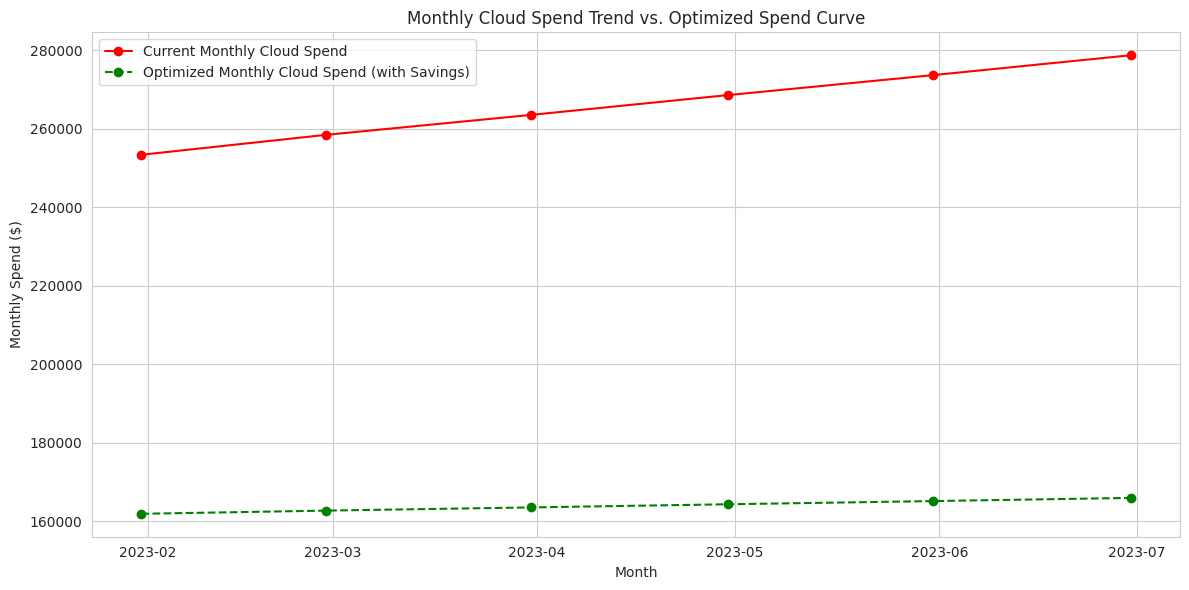


Top 5 Instances with Highest Potential Savings:


,instance_id,cloud_provider,monthly_cost,total_potential_savings_instance
4326,instance_04326,AWS,123.808806,136.189686
1791,instance_01791,GCP,100.499723,120.599667
154,instance_00154,AWS,108.319005,119.150905
2667,instance_02667,AWS,104.245511,114.670062
4230,instance_04230,AWS,103.651598,114.016757



Overall Spend Summary:


,Metric,Value ($)
0,Current Monthly Spend,253334.764180
1,Optimized Monthly Spend,161902.510927
2,Total Potential Monthly Savings,91432.253253


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Calculate total current monthly spend and total optimized monthly spend
current_monthly_spend = df['monthly_cost'].sum()
optimized_monthly_spend = current_monthly_spend - df['total_potential_savings_instance'].sum()

# For trend visualization, let's simulate 6 months of data based on current and optimized spend
months = pd.date_range(start='2023-01-01', periods=6, freq='ME') # Changed 'M' to 'ME' as recommended by FutureWarning

# Simulate a slight increase in current spend over time for demonstration
current_spend_trend = [current_monthly_spend * (1 + i * 0.02) for i in range(6)] # 2% increase per month

# Simulate a more stable optimized spend, perhaps with initial ramp-up in savings
optimized_spend_trend = [optimized_monthly_spend * (1 + i * 0.005) for i in range(6)] # 0.5% increase per month post-optimization

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(months, current_spend_trend, marker='o', linestyle='-', color='red', label='Current Monthly Cloud Spend')
plt.plot(months, optimized_spend_trend, marker='o', linestyle='--', color='green', label='Optimized Monthly Cloud Spend (with Savings)')

plt.title('Monthly Cloud Spend Trend vs. Optimized Spend Curve')
plt.xlabel('Month')
plt.ylabel('Monthly Spend ($)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Display a summary table of recommendations (from the previous cell's df)
print("\nTop 5 Instances with Highest Potential Savings:")
display(df.sort_values(by='total_potential_savings_instance', ascending=False)[['instance_id', 'cloud_provider', 'monthly_cost', 'total_potential_savings_instance']].head(5))

print("\nOverall Spend Summary:")
summary_data = {
    'Metric': ['Current Monthly Spend', 'Optimized Monthly Spend', 'Total Potential Monthly Savings'],
    'Value ($)': [current_monthly_spend, optimized_monthly_spend, df['total_potential_savings_instance'].sum()]
}
summary_df = pd.DataFrame(summary_data)
display(summary_df)